# Imports

In [1]:
# suppress TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TQDM_DISABLE_AUTO"] = "true"

import sys
sys.path.append('../')
import Preprocess2 
import Sample
import Plot_helper
from lr_find import LrFinder

import datetime
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
sys.path.pop()
sys.path.append('.././Final_solution')
import Bijectors, MAF_spline, RealNVP, Trainer, ConditionalBijectorWrapper , Utils
%load_ext autoreload
%autoreload 2
%aimport Trainer
import numpy as np
from typing import List, Tuple, Dict, Union, Optional, Any
import h5py
from pathlib import Path
from tqdm import tqdm
import math
import time
import subprocess
import matplotlib.pyplot as plt
import logging

# ==================== Suppress TensorFlow Warnings ====================
logging.getLogger('tensorflow').setLevel(logging.ERROR)
try:
    from absl import logging as absl_logging
    absl_logging.set_verbosity(absl_logging.ERROR)
except ImportError:
    pass
tf.get_logger().propagate = False

# ==================== Set up TensorFlow GPU memory management ====================
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


mother_output_dir = '../outputs/'

def get_gpu_info() -> Optional[List[str]]:
    try:
        gpu_info: str = subprocess.check_output(["nvidia-smi", "--query-gpu=gpu_name", "--format=csv,noheader"]).decode('utf-8')
        return gpu_info.strip().split('\n')
    except Exception as e:
        print(e)
        return None
gpu_models: Optional[List[str]] = get_gpu_info()
if gpu_models:
    training_device: str = gpu_models[0]
    print("Successfully loaded GPU model: {}".format(training_device))
else:
    training_device = 'undetermined'
    print("Failed to load GPU model. Defaulting to 'undetermined'.")

# ==================== Load High-Level Features plotter helper ====================
sys.path.pop()
sys.path.append('/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code')
from HighLevelFeatures import HighLevelFeatures as HLF
# Load the high-level features for the dataset
HLF_2 = HLF('electron', filename='/teo_fs_fast/users/acosso/Dataset/CaloChallenge_code/code/binning_dataset_2.xml')

Successfully loaded GPU model: NVIDIA L40S
[0, 144, 288, 432, 576, 720, 864, 1008, 1152, 1296, 1440, 1584, 1728, 1872, 2016, 2160, 2304, 2448, 2592, 2736, 2880, 3024, 3168, 3312, 3456, 3600, 3744, 3888, 4032, 4176, 4320, 4464, 4608, 4752, 4896, 5040, 5184, 5328, 5472, 5616, 5760, 5904, 6048, 6192, 6336, 6480]


# Trainer helpers

## Complire kwargs

In [2]:
def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float,
                        beta_1_scheduler = None,
                        clipnorm=None,
                        clipvalue = None
                       ):
    
    
    compiler_kwargs = { #'optimizer': optimizer,
                        #'optimizer': {'class_name': 'Custom>Adam',
                        'optimizer': {'class_name': 'Adam',
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True,
                                                'clipnorm': clipnorm,
                                                'clipvalue': clipvalue}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans,\
                                               'debug_print_mode': False}}],
                       #"compile_kwargs": {"run_eagerly": True},
                       'loss': {'class_name': 'MinusLogProbLoss',
                                'config': {'name': "MLP",
                                           'ignore_nans': ignore_nans,
                                           'nan_threshold': nan_threshold,
                                           'debug_print_mode': False}},
                       'momentum_scheduler' : {'scheduler' : beta_1_scheduler}
                        }
    return compiler_kwargs

## Callback kwargs

In [3]:
def get_callbacks_kwargs(checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float,
                         # ===================== new parameters =====================
                         spline_knots: int,
                         range_min: float,
                         batch_size: int,
                         x_train: tf.Tensor,
                         y_train: tf.Tensor,
                         ndims: int,
                         total_steps: int = 1000,
                         warmup_epochs: int = 18,
                         cooldown_epochs: int = 18,
                         annihilation_epochs: int = 4,
                         ):
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        {'class_name': 'ModelCheckpoint',
                         'config': {'filepath': checkpoint_path,
                                    'monitor': 'val_loss',
                                    'save_best_only': True,
                                    'save_weights_only': True,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss',
                                    'min_delta': es_min_delta,
                                    'patience': es_patience,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'baseline': None,
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau',
                         'config': {'monitor': 'val_loss',
                                    'factor': lr_reduce_factor,
                                    'min_delta': lr_min_delta,
                                    'patience': lr_patience,
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}},
                        #{'class_name': 'TensorBoardWithCustomSummaries',
                        # 'config': {
                        #             'log_dir': "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
                        #             'probe_y': x_train[:batch_size].numpy(),
                        #             'probe_cond': x_train[:batch_size, ndims:].numpy(),
                        #             'spline_knots': spline_knots,
                        #             'range_min': range_min,
                        #             'histogram_freq': 0,
                        #             'write_graph': False,
                        #             'update_freq': 'batch',
                        #             'profile_batch': 0}}
                        #{'class_name': 'CatchAndDebugNaN_RQS',
                        # 'config': {'spline_knots': spline_knots,
                        #            'range_min':   range_min,
                        #            'batch_size':  batch_size,
                        #            'ndims' : ndims, 
                        #            # the x_train & y_train values are passed through so the
                        #            # callback can build its own tf.data.Dataset
                        #            'x':           x_train,
                        #            'y':           y_train}},
                        {'class_name': 'OneCycleMomentum',
                                       'config': {'optimizer': None,          # placeholder; Trainer will fill
                                                  'total_steps': int(total_steps),
                                                  'pct_start':   warmup_epochs / (warmup_epochs + cooldown_epochs + annihilation_epochs),  # 18/40 = 0.45
                                                  'max_momentum': 0.95,
                                                  'base_momentum': 0.85}}
                                                         ]
    return callbacks_kwargs


## Fit kwargs

In [4]:
def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size,
                  'epochs': epochs_input,
                  'validation_data': validation_data,
                  'shuffle': shuffle,
                  'verbose': verbose}
    return fit_kwargs

## IO kwargs

In [5]:
def get_io_kwargs(path_to_results: str) -> Dict[str,Any]:
    return {'results_path': path_to_results,
            'load_weights': True,
            'load_results': True,}

# Bijector init

In [6]:
layer_energies = True
MODE = 'A' 

In [7]:
bijector_name = 'MsplineN'
spline_knots = 8
range_min = -14
eps_regulariser = 1e-4
regulariser = 'l2'
if MODE == 'A':
    ndims = 10 
    ncond = 31 if layer_energies else 26
else: 
    ndims = 12
    ncond = 57 if layer_energies else 56
n_hidden=[128, 128]
num_bijectors = 4
activation='relu'
kernel_constraint = None
#kernel_constraint = tf.keras.constraints.MaxNorm(5.0)
bias_initializer=tf.keras.initializers.Constant(0.01)
#bias_initializer = tf.keras.initializers.Zeros()
MAF = Bijectors.ChooseCondBijector(bijector_name, ndims, spline_knots, 
                            num_bijectors, range_min, n_hidden, activation, 
                            regulariser, eps_regulariser, conditional_event_shape=(ncond,),
                            input_structure = None, 
                            bias_initializer=bias_initializer, 
                            kernel_constraint=kernel_constraint,
                            shuffle = 'RandomShuffle',
                            perm_style = 'reverse',
                            batch_norm=False,
                            conditional_input_layers='first_layer',
                            tails='linear')


[<tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_0' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.Permute 'perm_1' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp.bijectors.MaskedAutoregressiveFlow 'masked_autoregressive_flow' batch_shape=[] forward_min_event_ndims=1 inverse_min_event_ndims=1 dtype_x=? dtype_y=?>, <tfp

In [8]:
base_dist = tfd.MultivariateNormalDiag(loc=tf.zeros(ndims, dtype=tf.float64), scale_diag=tf.ones(ndims, dtype=tf.float64))

# Trainer init, will only function as a data loader

## Dummy data

In [9]:

if MODE == 'A':
    D_total = 41 if layer_energies else 36 
else:
    D_total = 69 if layer_energies else 68 
precision = tf.float64 

dummy_sample = tf.zeros([1, D_total], dtype=precision)


## Init

In [10]:
run_number: int = 53
n_runs: int = 1

### Base run directory ###
path_to_results , _ = Utils.define_run_dir(mother_output_dir+'run_'+str(run_number)+'/',
                                           force = "skip",
                                           bkp = False)

### Compiler hyperparameters ###
lr: float = 5e-5
ignore_nans: bool = False
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
path_to_weights: str = Utils.define_dir(os.path.join(path_to_results, 'weights'))
checkpoint_path: str = os.path.join(path_to_weights, 'best_weights.h5')
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialize training hyperparameters ###
batch_size: int =  60000
epochs_input: int = 40
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False

Directory ../outputs/run_53/ already exists.
Skipping it.


In [11]:
from importlib import reload
#reload(Trainer)

NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                        flow = MAF, 
                                        x_data_train = dummy_sample,
                                        y_data_train = dummy_sample,
                                        io_kwargs = get_io_kwargs(path_to_results = path_to_results),
                                        compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                ignore_nans = True,
                                                                                nan_threshold = nan_threshold),
                                        callbacks_kwargs = get_callbacks_kwargs(checkpoint_path = checkpoint_path,
                                                                                es_min_delta = es_min_delta,
                                                                                es_patience = es_patience,
                                                                                lr_reduce_factor = lr_reduce_factor,
                                                                                lr_min_delta = lr_min_delta,
                                                                                lr_patience = lr_patience,
                                                                                min_lr = min_lr,
                                                                                batch_size = batch_size,
                                                                                spline_knots = spline_knots,
                                                                                range_min = range_min,
                                                                                x_train = dummy_sample,
                                                                                y_train = dummy_sample,
                                                                                ndims = ndims,),
                                        fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                    epochs_input = epochs_input,
                                                                    validation_data = (dummy_sample, dummy_sample),
                                                                    shuffle = shuffle,
                                                                    verbose = verbose_trainer),
                                        debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

********************************************found custom MAF
********************** using conditionals in a chain *********************
Model defined.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 41)]              0         
                                                                 
 log_prob (LogProbLayer)     (None,)                   412464    
                                                                 
Total params: 412,464
Trainable params: 412,464
Non-trainable params: 0
_________________________________________________________________
Model summary:  None
self.optimizer_config: {'class_name': 'Adam', 'config': {'learning_rate': 5e-05, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': True, 'clipnorm': None, 'clipvalue': None}}
optimizer: <keras.optimizers.legacy.adam.Adam object at 0x7fb0105e6cd0>
type(optimizer): <cla

## Weights histogram

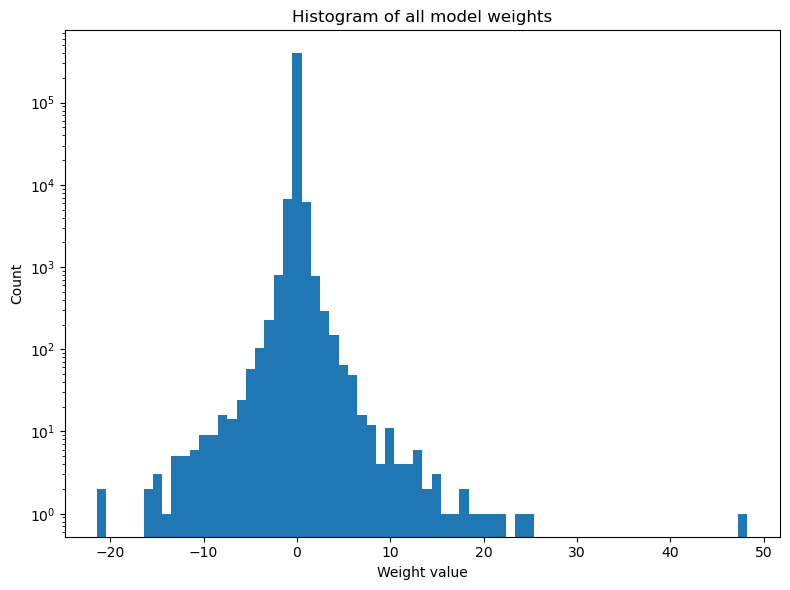

In [12]:
# 1. Grab all trainable variables from your Keras model
#    (this will include every weight/bias in your MAF/RQS networks,
#     because TFP tracks them as part of the model once you called fit)
vars = NFObject.model.trainable_weights

# 2. Pull them out as a flat NumPy array
all_w = np.concatenate([w.numpy().ravel() for w in vars])

# 3. Plot
plt.figure(figsize=(8,6))
plt.hist(all_w, bins=70)
plt.xlabel("Weight value")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Histogram of all model weights")
plt.tight_layout()
plt.show()

In [13]:
MODE = 'A'
showers_raw, cs, E_inc, fine_flat, cond_flat, factors = Preprocess2.build_and_cache(
    raw_h5     = "/teo_fs_fast/users/acosso/Dataset/dataset_2_2.hdf5",
    cache_file = "/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    mode       = MODE,
    E_coarse_max_ref = None,  # Set to None to use the maximum from the dataset
    force_rebuild = False,
    verbose = True, 
    noise_scale=1e-4,
    compression = 'lzf'
)

[build_and_cache] Loading from cache.


In [14]:
sys.path.append('../')
import GMetrics # type: ignore
from GMetrics.plotters import plot_corners, cornerplotter, plot_corr_matrix, plot_corr_matrix_side_by_side # type: ignore
from GMetrics.more import deformations # type: ignore
from GMetrics.more.optimizers_deformations import compute_exclusion_bisection, compute_exclusion_LR_bisection # type: ignore
from GMetrics.utils import se_mean, se_std, NumpyDistribution
from GMetrics.notebooks import shared
try:
    from GMetrics.base import NumpyDistribution
except ImportError:
    try:
        from GMetrics.more import NumpyDistribution
    except ImportError:
        from GMetrics.utils import NumpyDistribution

import pandas as pd

/teo_fs_fast/software/miniforge/envs/acosso_tf2_12_falkon/lib/python3.11/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [15]:
from GMetrics.utils import NumpyDistribution
class EmpiricalNumpyDistribution(NumpyDistribution):
    def __init__(self, data: np.ndarray, dtype: np.dtype = np.float32):
        """
        Initialize with your numeric data and ensure the dtype is consistent.
        
        Args:
            data (np.ndarray): The empirical data to sample from.
            dtype (np.dtype): The desired data type for the output samples.
        """
        if not isinstance(data, np.ndarray):
            raise ValueError("Data must be a numpy ndarray.")
        
        self.data = data
        self.dtype = dtype
        self.ndims = data.shape[1]  # Number of features (columns)
        self.nsamples = data.shape[0]  # Number of samples (rows)
    
    def sample(self, n: int, seed: int = None) -> np.ndarray:
        """
        Sample `n` data points with replacement from the stored data.

        Args:
            n (int): The number of samples to return.
            seed (int): The seed for random number generation to ensure reproducibility.

        Returns:
            np.ndarray: A batch of resampled data with shape (n, self.ndims).
        """
        # Use the seed to make the sampling deterministic
        rng = np.random.default_rng(seed)

        # Resample with replacement
        indices = rng.choice(self.nsamples, size=n, replace=True)
        resampled_data = self.data[indices]
        
        # Ensure the output has the desired dtype
        return resampled_data.astype(self.dtype)


In [16]:
from eval_streaming import evaluate_flow_and_cache

evaluate_flow_and_cache(
    in_cache_h5="/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    flow=MAF,
    base_dist=base_dist,
    gpu_batch=65536,          # lower if you still see OOM (e.g. 16384)
    io_chunk_rows=2_000_000,  # disk I/O window; 0.5–2M is usually sweet-spot
    start_row=0,
    n_rows=None,              # None = process to the end
    tf_dtype=tf.float64,
    save_as_float32=True,     # shrinks result file by ~2x
    clip_latent=False,
    latent_clip_value=4.0,
    compression="lzf",
    seed=42,
    overwrite=False,
)

[DONE] Wrote 64,800,000 rows to /teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5


In [17]:
from make_eval_features import build_eval_features

meta = build_eval_features(
    results_h5="/teo_fs_fast/users/acosso/Dataset/eval_results_A.hdf5",
    truth_h5="/teo_fs_fast/users/acosso/Dataset/eval_dataset_A.hdf5",
    out_h5="/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    io_chunk_events=100_000,
    compression="lzf",
    overwrite=False,
)

[build_eval_features] Output file already exists: /teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5
  overwrite flag is False → skipping feature computation.
  Existing file has N_events=100000, nz=9, zf=5, fine layers=45


# Evaluating total energy

## directory path

In [18]:
#model_dir = "./53/"
model_dir = os.path.join("./", str(run_number) + "/total_energy_batchsize_5k/")
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


## loading data

In [19]:
import utils_eval
reload(utils_eval)

<module 'utils_eval' from '/auto_home/users/acosso/Thesis/evaluation/utils_eval.py'>

In [20]:
sum_true, sum_gen, meta = utils_eval.load_total_energies(
    "/teo_fs_fast/users/acosso/Dataset/eval_features_A.hdf5",
    dtype=np.float32,
)

print(sum_true.shape, sum_gen.shape)  # expect (100000, 1) (100000, 1)
print(meta)

(100000, 1) (100000, 1)
{'N_events': 100000, 'Df': 6480, 'nz': 9, 'na': 8, 'nr': 9, 'zf': 5, 'af': 2, 'rf': 1, 'storage_mode': 'per_voxel_rows'}


In [21]:
orig = sum_true.copy()   # keep original intact
rng1 = np.random.default_rng(420)
perm1 = rng1.permutation(len(orig))
input_true1 = orig[perm1].copy()

rng2 = np.random.default_rng(421)
perm2 = rng2.permutation(len(orig))
input_true2 = orig[perm2].copy()
print(input_true1.shape, input_true2.shape)
input_sum_true1 = EmpiricalNumpyDistribution(input_true1.copy(), dtype=np.float32)
input_sum_true2 = EmpiricalNumpyDistribution(input_true2.copy(), dtype=np.float32)



(100000, 1) (100000, 1)


## input builder 

In [22]:
batch_size_test = 5000
niter = 1000
seed_test = 42
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = input_sum_true1,
                                                   dist_2_input = input_sum_true2,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 1, # not used if numerical samples are provided
                                                   small_sample_threshold = 1,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = False, 
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.
nsamples 5000000
batch_size 5000
niter 1000
niter * batch_size 5000000
small_sample False


## metric init

In [23]:
nslices = 100
fgd_num_points = 10
fgd_num_batches = 20

In [24]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
#SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
#                           nslices = nslices, # to be included in metric kwargs
#                           seed_slicing = 0, # to be included in metric kwargs
#                           progress_bar = True,
#                           verbose = True)
#SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
#                               nslices = nslices, # to be included in metric kwargs
#                               seed_slicing = 0, # to be included in metric kwargs
#                               progress_bar = True,
#                               verbose = True)

FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = fgd_num_batches, # to be included in metric kwargs
                               num_points = fgd_num_points, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs


In [25]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,is_symb_1,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample
0,1000,5000,1,1,float32,42,False,False,None,True,True,1,0,True,1,0,float32,1,5000000,False


In [26]:
TwoSampleTestInputs.ndims

1

In [27]:
ndims = TwoSampleTestInputs.ndims
max_vectorize = 45*200
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {
                                "fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": fgd_num_batches,
                                                  "num_points": fgd_num_points,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                                "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": max_vectorize,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               #"sks": {"name": "sks",
                               #        "object_name": "SKSTest",
                               #        "class_name": "GMetrics.SKSTest", 
                               #        "kwargs": {"nslices": nslices, 
                               #                   "seed_slicing": 0},
                               #        "result_key": "metric_means", 
                               #        "scale_func": lambda ns, _ : np.sqrt(ns),
                               #        "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                               #        "test_config": test_config_null,
                               #        "max_vectorize": max_vectorize,
                               #        "latex": "$t_{\mathrm{SKS}}$",
                               #        "null_file": null_hypotheses_dir+"SKS.json"},
                               #"swd": {"name": "swd",
                               #        "object_name": "SWDMetric",
                               #        "class_name": "GMetrics.SWDMetric", 
                               #        "kwargs": {"nslices": nslices, 
                               #                   "seed_slicing": 0},
                               #        "result_key": "metric_means", 
                               #        "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                               #        "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                               #        "test_config": test_config_null,
                               #        "max_vectorize": max_vectorize,
                               #        "latex": "$t_{\mathrm{SW}}$",
                               #        "null_file": null_hypotheses_dir+"SWD.json"}
                               }}

## Null hypothesis evaluation

In [28]:
import inspect

for metric in list(metrics_config[unique_key].values()):
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric.get("max_vectorize", None)
    obj = eval(metric["object_name"])

    os.makedirs(os.path.dirname(file), exist_ok=True)

    use_tf_flag = getattr(obj.Inputs, "use_tf", False)
    test_fn = getattr(obj, "Test_tf", None) if use_tf_flag else getattr(obj, "Test_np", None)
    if test_fn is None:
        raise RuntimeError(f"{name}: no test function for use_tf={use_tf_flag}")

    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and saving {name} (use_tf={use_tf_flag})")
        sig = inspect.signature(test_fn)
        call_kwargs = {}
        if "max_vectorize" in sig.parameters and max_vectorize is not None:
            call_kwargs["max_vectorize"] = max_vectorize
        test_fn(**call_kwargs)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)


Computing and saving fgd (use_tf=False)

------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 5000


Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [1:28:43<00:00,  5.32s/it]


Two-sample test calculation completed in 5323.2190530761145 seconds.
Saving fgd to ./53/total_energy_batchsize_5k/null_hypothesis/FGD.json
Computing and saving mmd (use_tf=False)

------------------------------------------
Starting MMD metric calculation...
niter = 1000
batch_size = 5000


...

Two-sample test calculation completed in 3824.5382941169664 seconds.
Saving mmd to ./53/total_energy_batchsize_5k/null_hypothesis/MMD.json
Computing and saving ks (use_tf=False)

------------------------------------------
Starting KS tests calculation...
niter = 1000
batch_size = 5000


Iterations:   4%|▎         | 37/1000 [00:00<00:02, 365.85it/s]

Running numpy KS tests...


Iterations: 100%|██████████| 1000/1000 [00:01<00:00, 520.70it/s]


Two-sample test calculation completed in 1.9230286970268935 seconds.
Saving ks to ./53/total_energy_batchsize_5k/null_hypothesis/KS.json


## Thresholds and summary

In [29]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values()):
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    #params = obj.Results[-1].__dict__  # parameters are in the result object
    #bs_used = int(params.get('batch_size_test_used', obj.Inputs.batch_size_test))
    #ns_eff = bs_used / 2.0
    #dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns_eff, ndims)
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)  # == nsamples/2
    dist_null = np.array(obj.Results[-1].result_value[result_key]) * scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
#metrics_config[unique_key]["lr"]["thresholds"] = [] #likelihood ratio test not computed

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric fgd: [[0.68, [680, 319], 33303029.773360007], [0.95, [950, 50], 104617968.04628985], [0.99, [990, 10], 179810095.2122395]]
Computing time for metric fgd: 5323.2190530761145
ThresholdS for metric mmd: [[0.68, [680, 319], 8.191759385889341e-05], [0.95, [950, 50], 0.0006428824684332479], [0.99, [990, 10], 0.0012189521878676057]]
Computing time for metric mmd: 3824.5382941169664
ThresholdS for metric ks: [[0.68, [680, 319], 0.9400000000000001], [0.95, [950, 50], 1.3599999999999999], [0.99, [990, 10], 1.7000000000000002]]
Computing time for metric ks: 1.9230286970268935


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7fb460db1da0>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 5000, 'batc...",100,$t_{\mathrm{FGD}}$,./53/total_energy_batchsize_5k/null_hypothesis...,"[[0.68, [680, 319], 33303029.773360007], [0.95..."
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7fae241a9260>,"lambda ns, ndims: 1","{'niter': 1000, 'batch_size_test': 5000, 'batc...",2,$t_{\mathrm{MMD}}$,./53/total_energy_batchsize_5k/null_hypothesis...,"[[0.68, [680, 319], 8.191759385889341e-05], [0..."
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7fae241a9120>,"lambda ns, _: np.sqrt(ns)","{'niter': 1000, 'batch_size_test': 5000, 'batc...",9000,$t_{\overline{\mathrm{KS}}}$,./53/total_energy_batchsize_5k/null_hypothesis...,"[[0.68, [680, 319], 0.9400000000000001], [0.95..."


## observed statistichs

In [30]:
orig_true = sum_true.copy()
orig_gen = sum_gen.copy()
rng1 = np.random.default_rng(1234)
rng2 = np.random.default_rng(5678)
shuffled_true = orig_true[rng1.permutation(orig_true.shape[0])]
shuffled_gen = orig_gen[rng2.permutation(orig_gen.shape[0])]
input_total_true = EmpiricalNumpyDistribution(shuffled_true.copy(), dtype=np.float32)
input_total_gen = EmpiricalNumpyDistribution(shuffled_gen.copy(), dtype=np.float32)

In [31]:
cache = model_dir + "/alternative_hypothesis/alt_hyp_total_energy_5k"
observed = utils_eval.compute_observed_distributions(
    metrics_config, unique_key,
    dist_1_num=input_total_gen,
    dist_2_num=input_total_true,
    ndims=ndims,
    batch_size_test=batch_size_test,
    niter_obs=1000,
    dtype=tf.float64, use_tf=False, verbose=True,
    cache_file=cache, overwrite=False, show_progress=True
)

[compute_observed_distributions] Using generalized inputs -> dist_1: numpy-distribution, dist_2: numpy-distribution
Parsing input distribution...
Input distribution is a NumpyDistribution object.
Parsing input distribution...
Input distribution is a NumpyDistribution object.


T_obs (niter=1000, batch=5000):   0%|          | 0/3 [00:00<?, ?it/s]


------------------------------------------
Starting FGD metric calculation...
niter = 1000
batch_size = 5000


Running numpy FGD calculation...


/auto_home/users/acosso/Thesis/evaluation/../GMetrics/metrics/fgd.py:436: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  metric, metric_error = JMetrics.fpd(dist_1_k, dist_2_k, **self.fgd_kwargs)
Iterations: 100%|██████████| 1000/1000 [2:25:53<00:00,  8.75s/it]


...

Iterations: 100%|██████████| 1000/1000 [1:05:00<00:00,  3.90s/it]


Two-sample test calculation completed in 3900.955958922161 seconds.
[done] mmd in 3900.99s  (niter=1000, batch=5000)

------------------------------------------
Starting KS tests calculation...
niter = 1000
batch_size = 5000


Running numpy KS tests...


Iterations: 100%|██████████| 1000/1000 [00:02<00:00, 495.12it/s]


Two-sample test calculation completed in 2.025225756224245 seconds.
[done] ks in 2.04s  (niter=1000, batch=5000)
[compute_observed_distributions] Cached results saved to: ./53/total_energy_batchsize_5k//alternative_hypothesis/alt_hyp_total_energy_5k


[warn] Found 3 metrics, fewer than expected_num_metrics=5.
[GRID] saved ./53/total_energy_batchsize_5k/null_vs_alt/config_ndims_1_nsamples_5000_niter_1000_null_vs_alt_PDF_grid_3.pdf


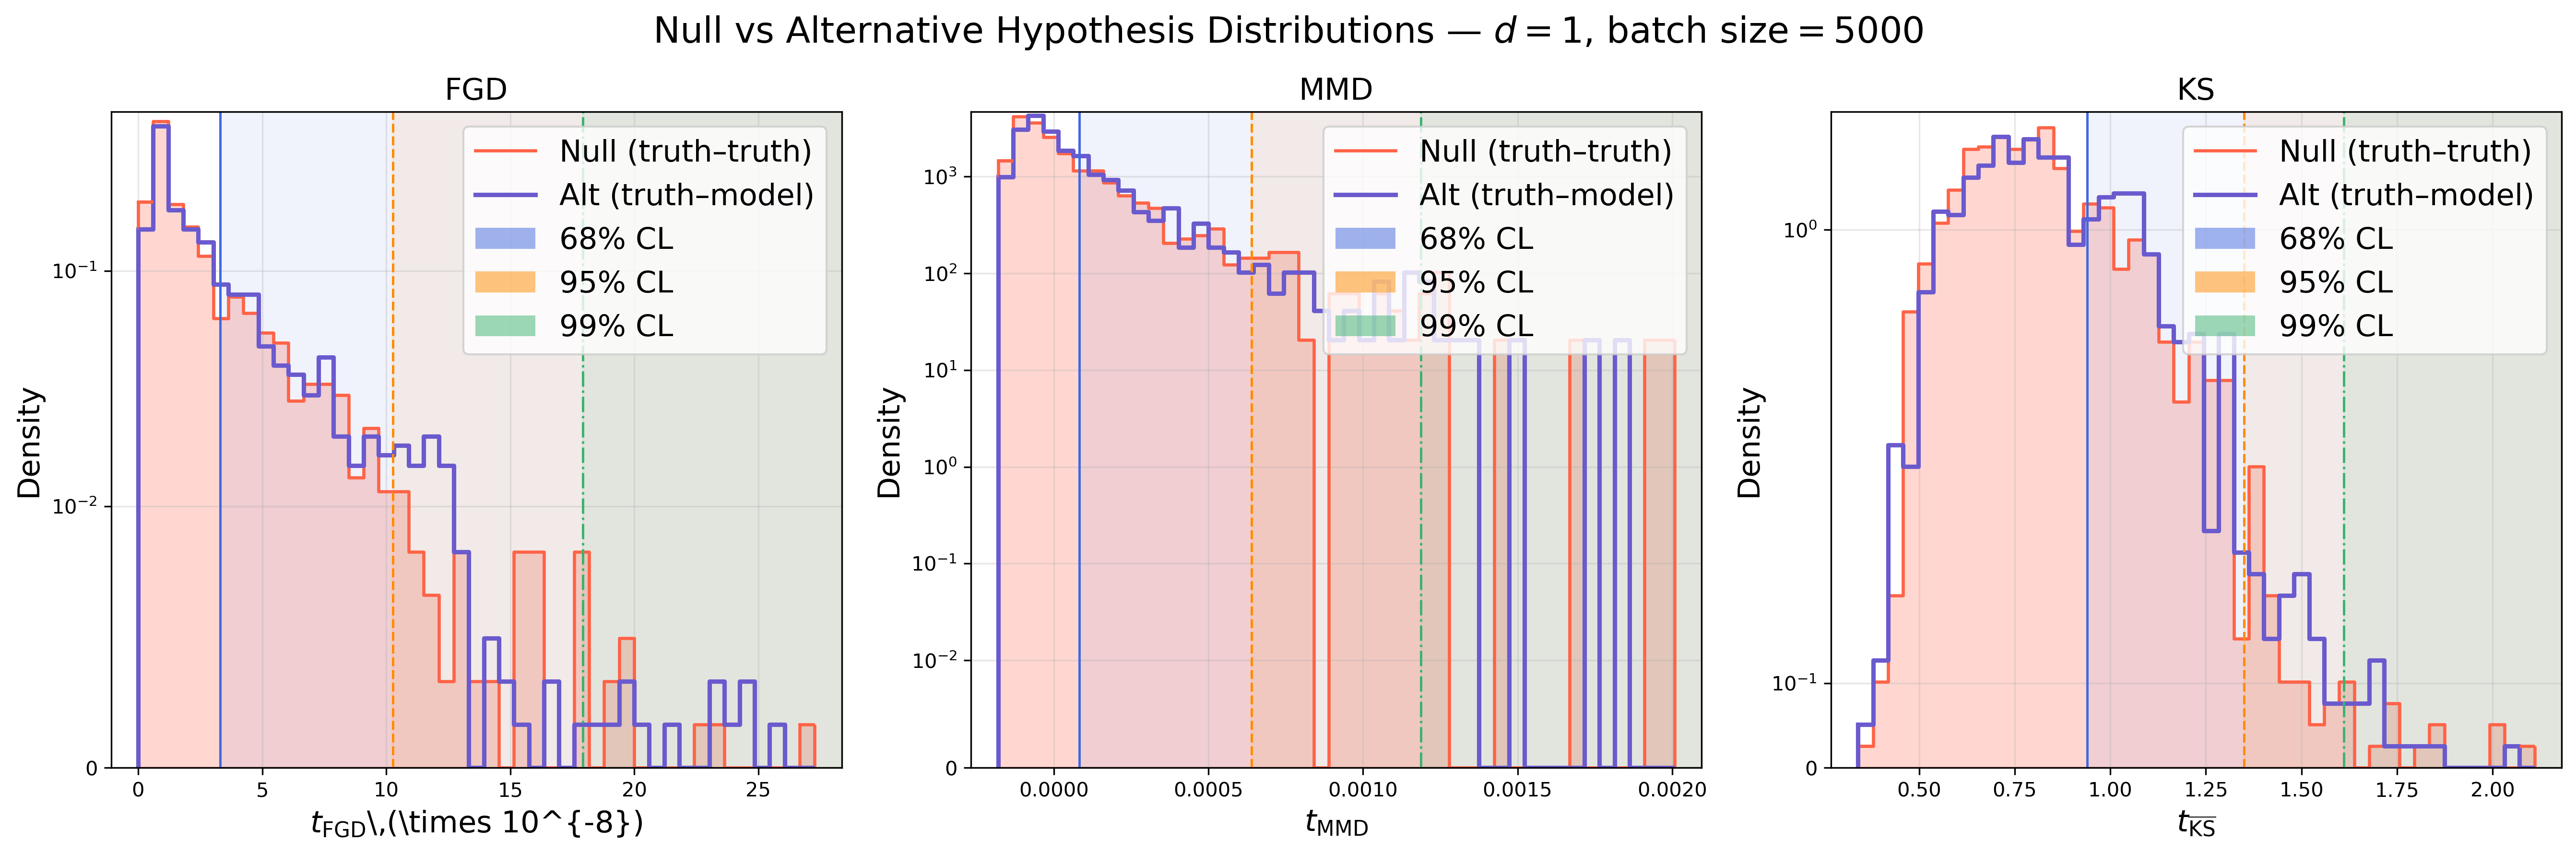

In [32]:
import eval_plotters
reload(eval_plotters)

# 2) Plot null vs alt (one PDF per metric with CL lines and rejection rates)
eval_plotters.plot_null_vs_alt_pdf(
    metrics_config = metrics_config,
    unique_key     = unique_key,
    observed       = observed,
    ndims          = ndims,
    save_dir       = os.path.join(model_dir, "null_vs_alt/"),
    num_bins=45,
    fill_null=True,
    null_alpha=0.25,
    ypad_frac=0.10,
    show_null_fill_legend = False,
    # FGD
    fgd_x_scale = "linear", fgd_x_linthresh = None,
    fgd_y_scale = "symlog", fgd_y_linthresh = 1e-2,
    # MMD
    mmd_x_scale = "linear", mmd_x_linthresh = 1e-3,
    mmd_y_scale = "symlog", mmd_y_linthresh = 1e-2,
    # KS
    ks_x_scale = "linear", ks_x_linthresh = None,
    ks_y_scale = "symlog", ks_y_linthresh = 5e-1,
    # SKS
    sks_x_scale = "linear", sks_x_linthresh = None,
    sks_y_scale = "symlog", sks_y_linthresh = 9e-1,
    # SWD
    swd_x_scale = "linear", swd_x_linthresh = None,
    swd_y_scale = "symlog", swd_y_linthresh = 9e-2,
    fgd_disp_scale = 1e-8,
    mmd_disp_scale = 1.0,
    ks_disp_scale = 1.0,
    sks_disp_scale = 1.0,
    swd_disp_scale = 1.0,
    show_scale_in_label = True,  # append "(×10^{k})" to xlabel if scale ≠ 1
    plotting_mode="multiple",
    expected_num_metrics=5,  # set what you expect
    batch_size_test=batch_size_test,
)


In [33]:
cache = "./" + str(run_number) + "/pvalues/pvalues_phys_feat/total_energy_5k.csv"
df_pvals, pvals = utils_eval.compute_pvalues_table(
    metrics_config=metrics_config,
    unique_key=unique_key,
    observed=observed,
    ndims=ndims,
    agg="median",        # or "mean"
    tail="right",        # or "left" / "two-sided"
    save_csv=cache,
    verbose=True,
)


metric,niter,batch_size,nslices,p_value,time_sec
FGD,1000,5000,-,0.454,-
MMD,1000,5000,-,0.465,-
KS,1000,5000,-,0.475,-


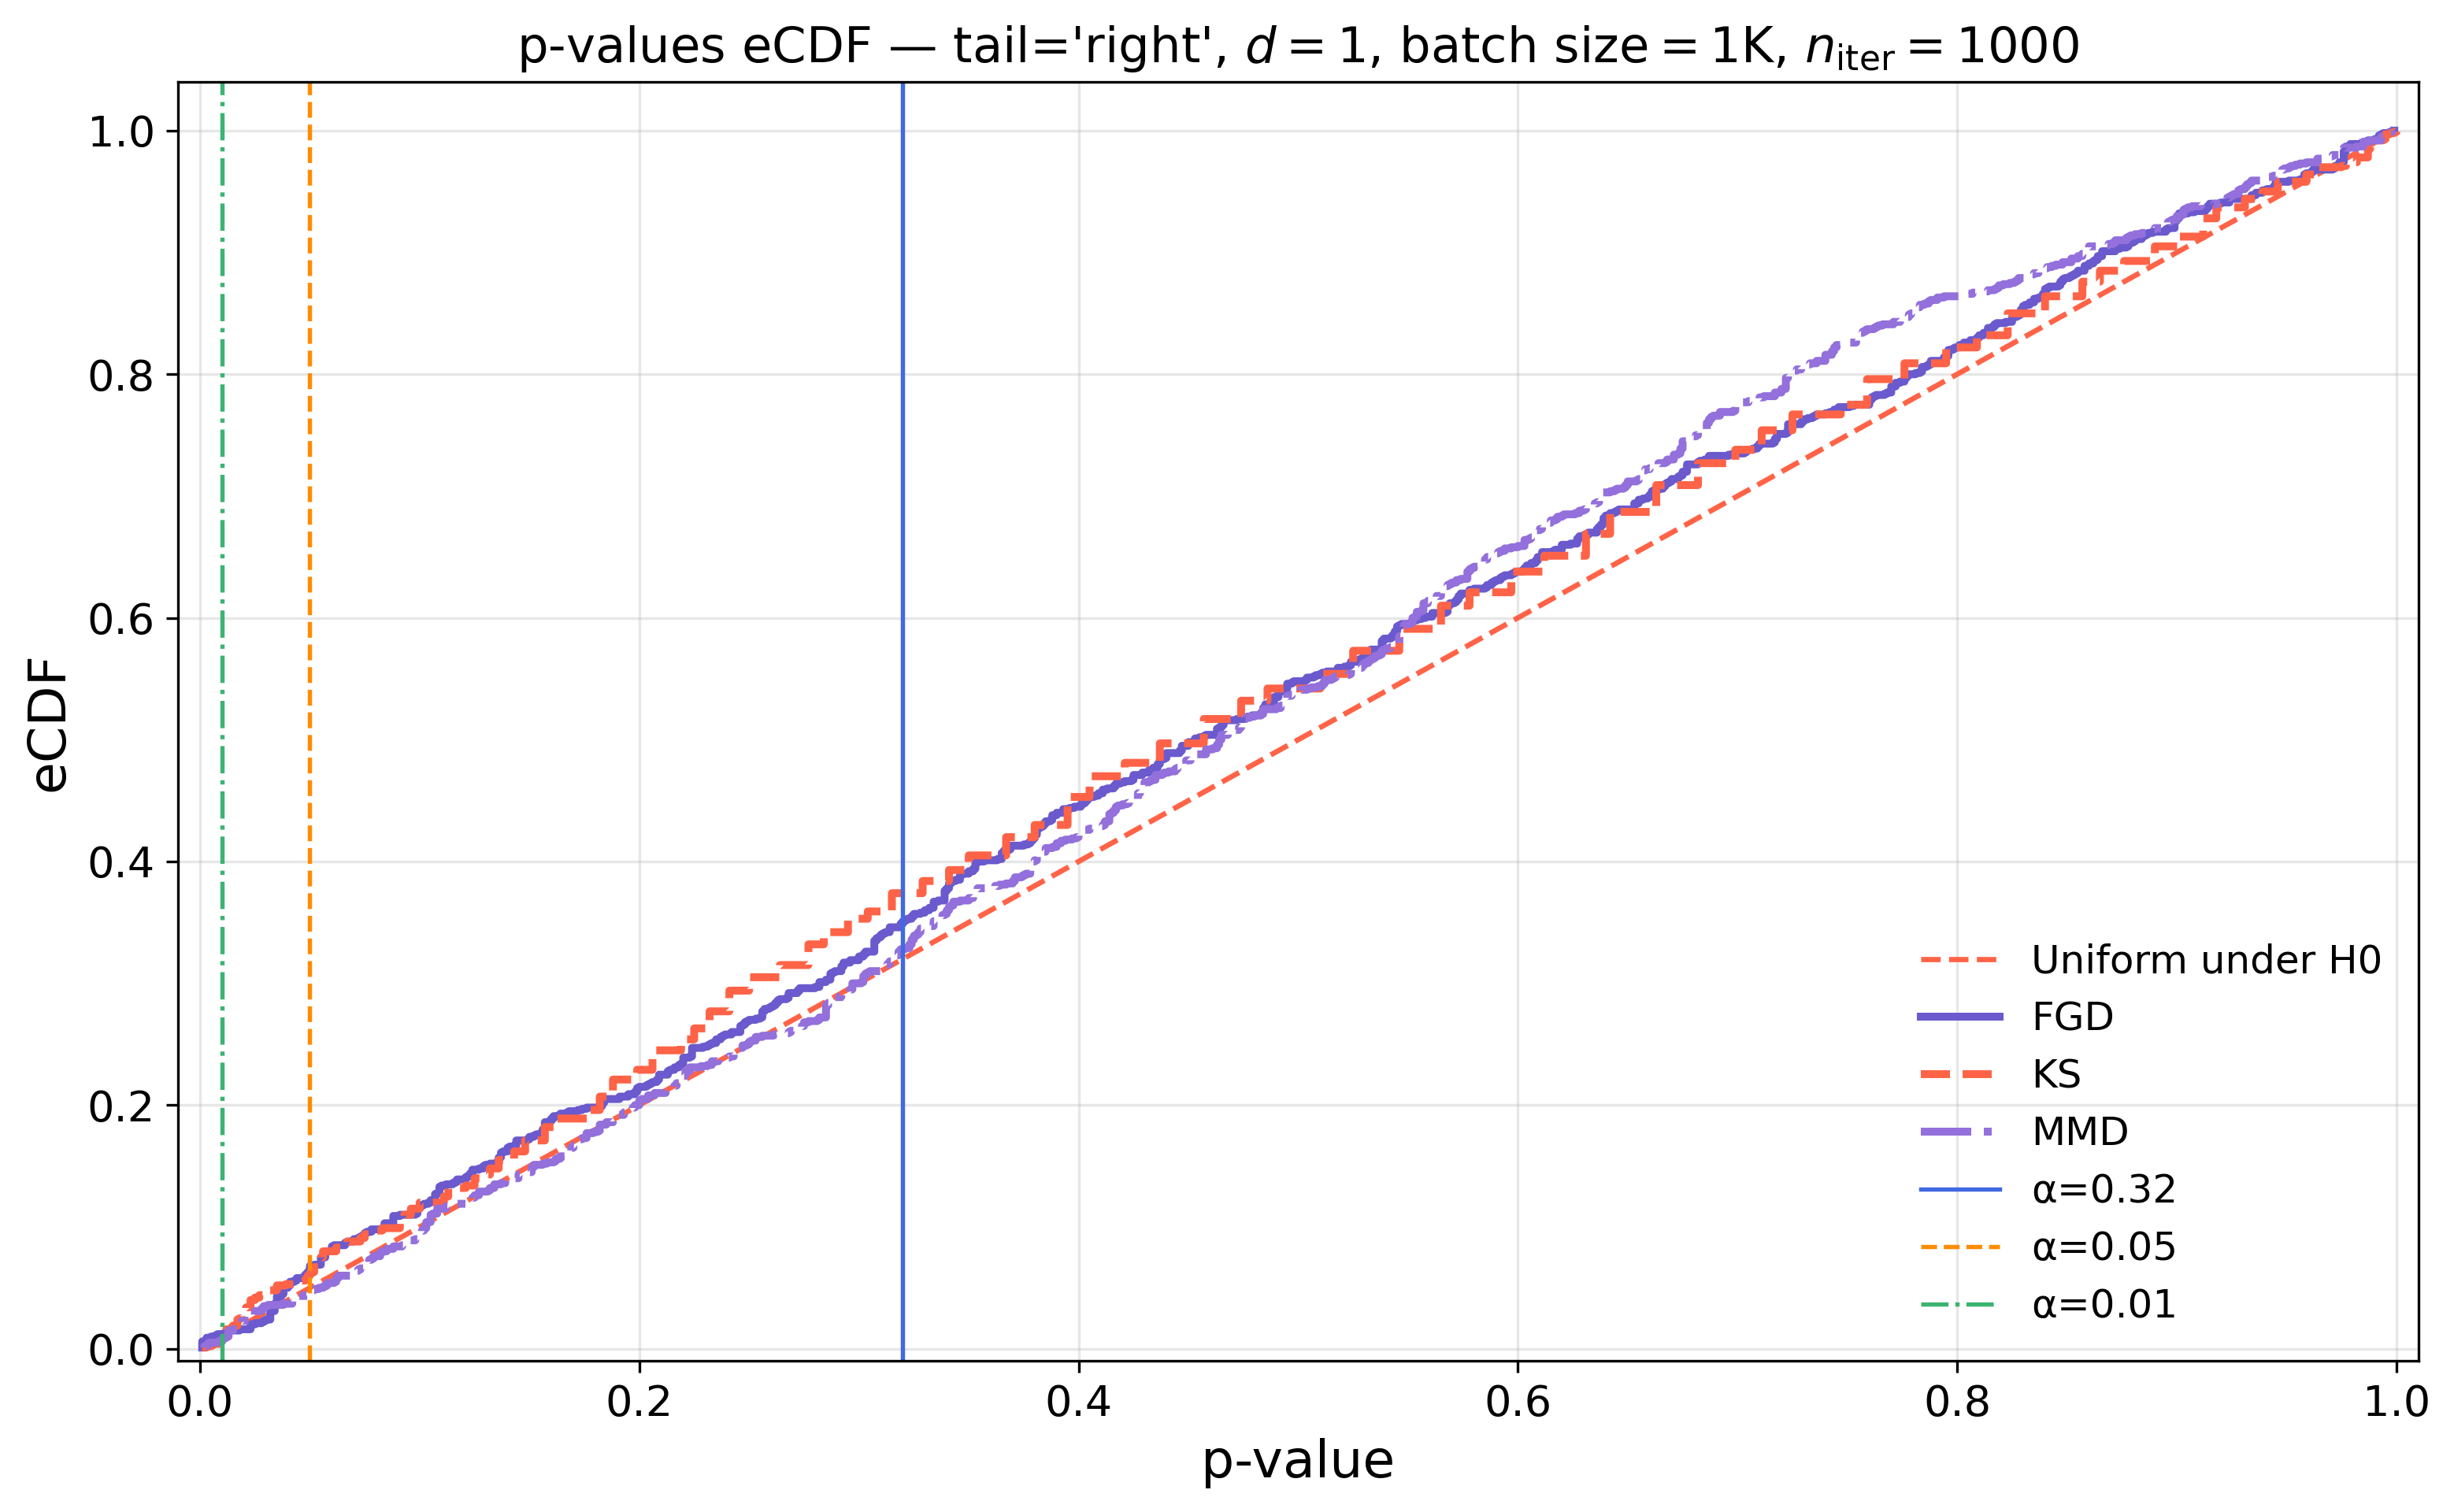

In [34]:
_ = eval_plotters.compute_and_plot_alt_pvalues(
    metrics_config,
    unique_key,
    observed,
    ndims,
    save_dir=None,
    num_bins = 40,
    top_pad_ecdf = 0.04,
    plot_kind = "cdf")